### Libraries

In [1]:
# Numerical libraries
import numpy as np
import pandas as pd
# from scipy.signal import savgol_filter

# Machine learning and data preprocessing libraries
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import MinMaxScaler

# Plotting library
import matplotlib.pyplot as plt

# TensorFlow and Keras libraries for deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.models import Sequential

# Other imports (if necessary)
from keras.layers import SimpleRNN as SimpleRNN_layer, LSTM as LSTM_layer
from keras.layers import Layer
from keras import backend as K
from keras.callbacks import EarlyStopping
import sys

# PCC model
from kinematics_functions import T_beModule, invKspace
from point_clouds import generate_random_points
from add_error_to_kin import add_error_to_kin
from ISTlogo_traj import ISTlogo_traj


## Data Collection

In [2]:
# jt2l = lambda p: ((p-316.1)/-2.468)

# cab_traj = generate_random_points(25, 160, 10000, 5)
# cab_traj_err = [add_error_to_kin(cab_traj[i+1], cab_traj[i], 0, 0, 0, 0, 0) for i in range(len(cab_traj)-1)]
# pcc_traj = [T_beModule(traj, [], 0, None)[:-1, 3] for traj in cab_traj[1:]]

# y_target = np.array(pcc_traj)
# x_train = np.array(cab_traj[1:])
# y_train = np.array([T_beModule(traj, [], 0, None)[:-1, 3] for traj in cab_traj_err])

# traj = np.array(ISTlogo_traj()[0])

# jtheta2len = lambda p: (p - 383.89841) / -2.53968 # polaris readings
# x_test = jtheta2len(traj)
# y_test = np.array([T_beModule(traj, [], 0, None)[:-1, 3] for traj in x_test])

# print(len(x_train), len(y_train), len(y_target))

# # Create the DataFrame
# df = pd.DataFrame({
#     'Servo_Angles': ["({}, {}, {})".format(*angs) for angs in x_train],
#     'Servo_Angles (w/ err)': ["({:.2f}, {:.2f}, {:.2f})".format(*angs) for angs in cab_traj_err],
#     'Target_Position': ["({:.2f}, {:.2f}, {:.2f})".format(*pos) for pos in y_target],
#     'Observed_Position': ["({:.2f}, {:.2f}, {:.2f})".format(*pos) for pos in y_train],
# })

# # Display the DataFrame
# df.head()


In [3]:
# read data from Polaris dataset
from read_datafile import parse_dataset, polaris2base
from kinematics_functions import T_beModule

# datasets = ["./data/dataset_1001_2023-11-14T123514.txt"]

datasets = ["./data/dataset_1001_2023-11-23T162547.txt",
            "./data/dataset_976_curv1_2023-11-27T154255.txt",
            "./data/dataset_301_2023-11-27T164142.txt",
            "./data/dataset_600_2023-12-15T175008.txt",
            "./data/dataset_1200_2023-12-13T161233.txt",
            "./data/dataset_224_curv1_2023-11-27T151127.txt" # for testing
           ]
# datasets.append(["./data/dataset_1001_2023-11-17T161724.txt", ])

datasets_result = []

for filename in datasets:
    traj, ref_T, pos = parse_dataset(filename)
    traj_, pos_base, est_pos_base = polaris2base(traj, ref_T, pos)
    datasets_result.append({"traj": traj, "traj_": traj_, "pos_base": pos_base, "est_pos_base": est_pos_base})

# print(datasets_result[0].get("traj").shape, '\n',
#       datasets_result[0].get("traj")[:5], '\n',
#       datasets_result[0].get("traj_")[:5], '\n',
#       datasets_result[0].get("pos_base")[:5], '\n',
#       datasets_result[0].get("est_pos_base")[:5], '\n',)


## Data Preprocessing

In [4]:
# # Custom Transformer for servo feedback filtration
# class ServoFeedbackFilter(BaseEstimator, TransformerMixin):
#     def fit(self, X, y=None):
#         return self

#     def transform(self, X, y=None):
#         return savgol_filter(X, 5, 3, axis=0)

# # Custom Transformer for relative angles
# class RelativeAngles(BaseEstimator, TransformerMixin):
#     def fit(self, X, y=None):
#         return self

#     def transform(self, X, y=None):
#         return np.diff(X, axis=1)

# # Preprocessing pipeline
# preprocessing_pipeline = Pipeline([
#     ('servo_feedback_filter', ServoFeedbackFilter()),
#     ('relative_angles', RelativeAngles()),
#     ('scaler', MinMaxScaler())
# ])

# # Using the pipeline to transform data
# processed_data = preprocessing_pipeline.fit_transform(servo_data)


In [5]:
# Polaris data preprocessing
y_train = []
x_train = []
y_test = []
x_test = []

for i, dataset in enumerate(datasets_result):
    rel_err_norm = np.linalg.norm(dataset.get("pos_base") - dataset.get("est_pos_base"), axis=1) / \
        np.linalg.norm(dataset.get("est_pos_base"), axis=1)
    pcc_err_tol = np.mean(rel_err_norm) + np.std(rel_err_norm).astype(float) * 0.5
    # print(max(rel_err_norm))
    mask = rel_err_norm < pcc_err_tol
    # print(len([j for j in mask if j]))
    if i == (len(datasets_result) - 1):
        # print(f"{i} test_append")       
        x_test += list(dataset.get("pos_base")[mask])
        y_test += list(dataset.get("traj_")[mask])
    else:
        # print(f"{i} train_append")       
        x_train += list(dataset.get("pos_base")[mask])
        y_train += list(dataset.get("traj_")[mask])

    # filtered_dataset = {key: value[rel_err_norm < .05] for key, value in dataset.items()}

x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)
print(f"Training Dataset: {len(x_train)}")
print(f"Test Dataset: {len(x_test)}")
# print(filtered_dataset.get("traj").shape, '\n',
#       filtered_dataset.get("traj")[:5], '\n',
#       filtered_dataset.get("traj_")[:5], '\n',
#       filtered_dataset.get("pos_base")[:5], '\n',
#       filtered_dataset.get("est_pos_base")[:5], '\n',)

# y_train = filtered_dataset.get("pos_base")
# x_train = filtered_dataset.get("traj_")

# print(filtered_dataset.get("traj").shape)
# print(x_train.shape[1])


Training Dataset: 3177
Test Dataset: 165


## Model Design & Selection

In [61]:
class DNNModelBuilder:
    def __init__(self, input_data, architectures):
        """
        :param input_data: data used to determine the input shape
        :param architectures: list of functions. Each function should return a compiled tf.keras.model.
        """
        self.input_data = input_data
        self.architectures = architectures
        self.models = [arch(input_data, *args) for arch, args in architectures]
        self.histories = []

    def train(self, data, labels, epochs=50, batch_size=32, validation_split=0.2):
        for i, model in enumerate(self.models):
            print(f"Training model {i + 1}/{len(self.models)}")
            early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=0, mode='min', restore_best_weights=True)
            history = model.fit(data, labels, epochs=epochs, batch_size=batch_size, validation_split=validation_split, verbose=0, callbacks=[early_stopping])
            self.histories.append(history)  # Store training history for future analysis

    def predict(self, data):
        predictions = []
        for model in self.models:
            predictions.append(model.predict(data))
        return predictions

    def evaluate(self, data, labels):
        """Evaluate models on given data and labels, returns loss values."""
        losses = []
        for model in self.models:
            loss = model.evaluate(data, labels)
            losses.append(loss)
        return losses

    def save_models(self, prefix="model"):
        """Store models to disk."""
        for i, model in enumerate(self.models):
            model.save(f"{prefix}_{i}.keras")

    def compare_models(self):
        """Compare training histories visually."""
        for i, history in enumerate(self.histories):
            plt.plot(history.history['val_loss'],
                     label=f"Model {i + 1}: {str(self.architectures[i][0]).split(' ')[1]}, {str(self.architectures[i][1][0])}")

        plt.title('Model Comparison on Validation Loss')
        plt.ylabel('Validation Loss')
        plt.xlabel('Epoch')
        plt.legend()
        plt.ylim([0, np.mean([np.mean(history.history['val_loss']) for history in self.histories]).astype(float) * 1.5])
        plt.show()


##### Several types of architectures

def mlp(data, layers, activation='relu', optimizer='adam', loss='mse'):
    input_shape = (data.shape[1],)
    model = Sequential()
    model.add(Dense(layers[0], activation=activation, input_shape=input_shape))
    if len(layers) > 1:
        for layer in layers[1:]:
            model.add(Dense(layer, activation=activation))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model

class RBFLayer(Layer):
    def __init__(self, units, gamma, **kwargs):
        super(RBFLayer, self).__init__(**kwargs)
        self.units = units
        self.gamma = K.cast_to_floatx(gamma)

    def build(self, input_shape):
        self.mu = self.add_weight(name='mu',
                                  shape=(int(input_shape[1]), self.units),
                                  initializer='uniform',
                                  trainable=True)
        super(RBFLayer, self).build(input_shape)

    def call(self, inputs):
        diff = K.expand_dims(inputs) - self.mu
        l2 = K.sum(K.pow(diff,2), axis=1)
        res = K.exp(-1 * self.gamma * l2)
        return res

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.units)

def SimpleRBFNN(data, optimizer='adam', loss='mse'):
    input_shape = (data.shape[1],)
    # input_layer = keras.layers.Input(shape=input_shape)
    model = Sequential()
    # model.add(Dense(20, activation='relu', input_shape=input_shape))
    model.add(RBFLayer(20, 0.5, input_shape=input_shape))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model

def ResNet(data, optimizer='adam', loss='mse'):
    """
    Deep Residual Network (ResNet)
    A deep network with skip connections.
    
    # Example Usage:
    model_resnet = ResNet(processed_data)
    model_resnet.fit(processed_data, target_positions, epochs=10)
    """
    input_shape = (data.shape[1],)
    input_layer = tf.keras.layers.Input(shape=input_shape)
    x = Dense(128, activation='relu')(input_layer)
    for _ in range(3):
        y = Dense(128, activation='relu')(x)
        y = Dense(128, activation='relu')(y)
        x = tf.keras.layers.add([x, y])
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    output_layer = Dense(3)(x)
    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=optimizer, loss=loss)
    return model

def DropoutDNN(data, optimizer='adam', loss='mse'):
    """
    Dropout Regularized (DNN)
    A feedforward architecture with dropout layers.
    
    # Example Usage:
    model_dropout = DropoutDNN(processed_data)
    model_dropout.fit(processed_data, target_positions, epochs=10)
    """
    input_shape = (data.shape[1],)
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model

def rnn(data, layers, optimizer='adam', loss='mse'):
    """
    Recurrent Neural Network (RNN)
    Useful for temporal sequences.

    layers: layers: list[args: tuple[units: int, ret_seq: bool]]
    """
    # Check for 3D shape, if not, try to reshape
    if len(data.shape) == 2:
        data = data.reshape(data.shape[0], data.shape[1], 1)
    input_shape = (data.shape[1], data.shape[2])
    model = Sequential()
    if len(layers) >= 2: 
        model.add(SimpleRNN_layer(layers[0][0], return_sequences=layers[0][1], input_shape=input_shape))
        for units, ret_seq in layers[1:-1]:
            model.add(SimpleRNN_layer(units, return_sequences=ret_seq))
        if layers[-2][1]:
            model.add(SimpleRNN_layer(layers[-1][0], return_sequences=False))
        else: model.add(Dense(layers[-1][0]))
    elif len(layers) == 1:
        model.add(SimpleRNN_layer(layers[-1][0], return_sequences=False))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    # print(model.summary())
    print(data.shape, '|', input_shape, '|', layers)
    return model

def SimpleRNN(data, optimizer='adam', loss='mse'):
    """
    Recurrent Neural Network (RNN)
    Useful for temporal sequences.
    """
    # Check for 3D shape, if not, try to reshape
    if len(data.shape) == 2:
        data = data.reshape(data.shape[0], data.shape[1], 1)
    input_shape = (data.shape[1], data.shape[2])
    print(data.shape, '\n', input_shape)
    model = Sequential()
    model.add(SimpleRNN_layer(30, return_sequences=True, input_shape=input_shape))
    model.add(SimpleRNN_layer(30, return_sequences=True))
    # model.add(SimpleRNN_layer(30))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    # print(model.summary())
    return model

def lstm(data, layers, optimizer='adam', loss='mse'):
    # Check for 3D shape, if not, try to reshape
    if len(data.shape) == 2:
        data = data.reshape(data.shape[0], data.shape[1], 1)
    input_shape = (data.shape[1], data.shape[2])
    model = Sequential()
    if len(layers) >= 2: 
        model.add(LSTM_layer(layers[0][0], return_sequences=layers[0][1], input_shape=input_shape))
        for units, ret_seq in layers[1:-1]:
            model.add(LSTM_layer(units, return_sequences=ret_seq))
        if layers[-2][1]:
            model.add(LSTM_layer(layers[-1][0], return_sequences=False))
        else: model.add(Dense(layers[-1][0]))
    elif len(layers) == 1:
        model.add(LSTM_layer(layers[-1][0], return_sequences=False))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    # print(model.summary())
    print(data.shape, '|', input_shape, '|', layers)
    return model

def LSTM_NN(data, optimizer='adam', loss='mse'):
    if len(data.shape) == 2:
        data = data.reshape(data.shape[0], data.shape[1], 1)
    input_shape = (data.shape[1], data.shape[2])
    # input_shape = data.shape
    model = Sequential()
    # input_layer = keras.layers.Input(shape=input)
    # model.add(Input(shape=input))
    model.add(LSTM_layer(30, return_sequences=True, input_shape=input_shape))
    model.add(LSTM_layer(30, return_sequences=False))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model


Training model 1/4
Epoch 1/1000
41/41 [==============================] - 1s 6ms/step - loss: 13568.8525 - val_loss: 11209.6641
Epoch 2/1000
41/41 [==============================] - 0s 2ms/step - loss: 8687.8096 - val_loss: 5578.1230
Epoch 3/1000
41/41 [==============================] - 0s 3ms/step - loss: 3115.1716 - val_loss: 1119.1830
Epoch 4/1000
41/41 [==============================] - 0s 2ms/step - loss: 475.8849 - val_loss: 178.6237
Epoch 5/1000
41/41 [==============================] - 0s 3ms/step - loss: 107.1194 - val_loss: 83.5564
Epoch 6/1000
41/41 [==============================] - 0s 2ms/step - loss: 57.2153 - val_loss: 51.0511
Epoch 7/1000
41/41 [==============================] - 0s 2ms/step - loss: 37.2453 - val_loss: 35.5897
Epoch 8/1000
41/41 [==============================] - 0s 2ms/step - loss: 27.7791 - val_loss: 28.3426
Epoch 9/1000
41/41 [==============================] - 0s 2ms/step - loss: 23.1217 - val_loss: 24.2958
Epoch 10/1000
41/41 [=========================

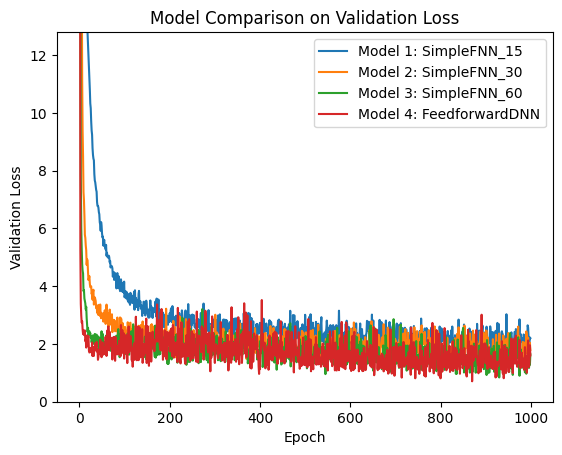

6/6 [==============================] - 0s 2ms/step - loss: 0.4894


In [12]:
# # Using the model builder
# builder = DNNModelBuilder(x_train, [(SimpleFNN_15, []), (SimpleFNN_30, []), (SimpleFNN_60, []), (FeedforwardDNN, [])])

# builder.train(x_train, y_train, epochs=1000, batch_size=64, validation_split=0.2)

# builder.compare_models()
# losses = builder.evaluate(x_test, y_test)
# # print(losses)
# # builder.save_models()

# #7m42

Model 1: mlp, [10]
Model 2: mlp, [20]
Model 3: mlp, [30]
Model 4: mlp, [60]
Model 5: mlp, [10, 10]
Model 6: mlp, [20, 20]
Model 7: mlp, [30, 30]
Model 8: mlp, [60, 60]
Model 9: mlp, [10, 10, 10]
Model 10: mlp, [20, 20, 20]
Model 11: mlp, [30, 30, 30]
Model 12: mlp, [60, 60, 60]


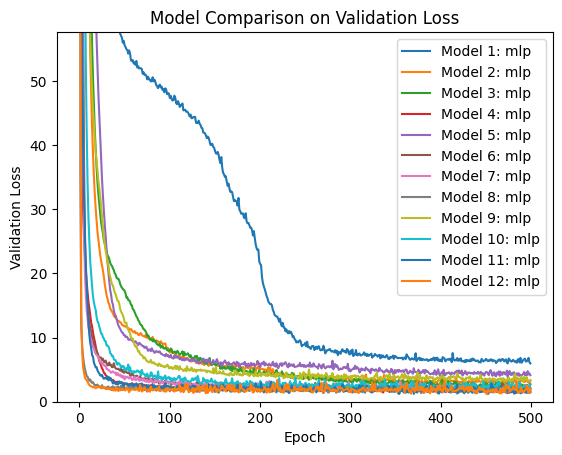

6/6 [==============================] - 0s 1ms/step - loss: 1.6523


In [36]:
# Using the model builder
# builder = DNNModelBuilder(x_train, [
#     (mlp, [[10]]),
#     (mlp, [[20]]),
#     (mlp, [[30]]),
#     (mlp, [[60]]),
#     (mlp, [[10, 10]]),
#     (mlp, [[20, 20]]),
#     (mlp, [[30, 30]]),
#     (mlp, [[60, 60]]),
#     (mlp, [[10, 10, 10]]),
#     (mlp, [[20, 20, 20]]),
#     (mlp, [[30, 30, 30]]),
#     (mlp, [[60, 60, 60]]),
#     ])

# builder.train(x_train, y_train, epochs=500, batch_size=64, validation_split=0.2)
for i, model in enumerate(builder.architectures):
    print(f"Model {i+1}: {str(model[0]).split(' ')[1]}, {model[1][0]}")
builder.compare_models()
losses = builder.evaluate(x_test, y_test)
# print(losses)
# builder.save_models()

# ~12min

In [11]:
# Plots for comparison of True and Prediction Positions
import plotly.graph_objects as go

def plot_positions_comparison(real_positions, predicted_positions):
    # Extracting x, y, z coordinates for real positions
    x_real = real_positions[:, 0]
    y_real = real_positions[:, 1]
    z_real = real_positions[:, 2]

    # Extracting x, y, z coordinates for predicted positions
    x_pred = predicted_positions[:, 0]
    y_pred = predicted_positions[:, 1]
    z_pred = predicted_positions[:, 2]

    # Creating the figure
    fig = go.Figure()

    fig.update_layout(
        autosize = False,
        width = 500,
        height = 500,
        )

    # Adding real positions trace
    fig.add_trace(go.Scatter3d(x=x_real, y=y_real, z=z_real,
                               mode='markers', 
                            #    mode='markers+lines', 
                               marker=dict(size=3, color='blue', symbol='circle'),
                               name='Real Positions'))

    # Adding predicted positions trace
    fig.add_trace(go.Scatter3d(x=x_pred, y=y_pred, z=z_pred,
                               mode='markers', 
                            #    mode='markers+lines', 
                               marker=dict(size=3, color='red', symbol='x'),
                               name='Predicted Positions'))

    # Update plot layout
    fig.update_layout(
        title='Real vs Predicted End Effector Positions',
        scene=dict(
            xaxis_title='Servo 1',
            yaxis_title='Servo 2',
            zaxis_title='Servo 3'
            # xaxis_title='X Axis',
            # yaxis_title='Y Axis',
            # zaxis_title='Z Axis'
        ),
        margin=dict(r=10, l=10, b=10, t=30)
    )

    # Show the plot
    fig.show()


In [24]:
pred = builder.predict(x_test)

for i, p in enumerate(pred):
    # plot_positions_comparison(np.array(y_test), np.array(p))
    rel_err = np.abs(np.linalg.norm(p - y_test, axis=1)) / np.abs(np.linalg.norm(y_test, axis=1)) * 100
    scale_err = np.abs(np.linalg.norm(p - y_test, axis=1)) / (np.max(y_test[:,0]) - np.min(y_test[:,0])) * 100
    print(f"\nArchitechture: {str(builder.architectures[i][0]).split(' ')[1]}, {builder.architectures[i][1][0]}")
    print(f"Mean Relative Error: {np.mean(rel_err):.3f}%")
    print(f"Max Relative Error: {max(rel_err):.3f}%")
    print(f"Mean Relative Full-Scale Error: {np.mean(scale_err):.3f}%")
    print(f"Max Relative Full-Scale Error: {max(scale_err):.3f}%")
    


Architechture: mlp, [10]
Mean Relative Error: 1.613%
Max Relative Error: 5.288%
Mean Relative Full-Scale Error: 5.475%
Max Relative Full-Scale Error: 18.533%

Architechture: mlp, [20]
Mean Relative Error: 1.267%
Max Relative Error: 3.124%
Mean Relative Full-Scale Error: 4.282%
Max Relative Full-Scale Error: 9.660%

Architechture: mlp, [30]
Mean Relative Error: 0.938%
Max Relative Error: 2.510%
Mean Relative Full-Scale Error: 3.167%
Max Relative Full-Scale Error: 8.416%

Architechture: mlp, [60]
Mean Relative Error: 0.868%
Max Relative Error: 2.207%
Mean Relative Full-Scale Error: 2.919%
Max Relative Full-Scale Error: 8.679%

Architechture: mlp, [10, 10]
Mean Relative Error: 1.185%
Max Relative Error: 2.870%
Mean Relative Full-Scale Error: 4.017%
Max Relative Full-Scale Error: 9.237%

Architechture: mlp, [20, 20]
Mean Relative Error: 0.894%
Max Relative Error: 2.411%
Mean Relative Full-Scale Error: 3.015%
Max Relative Full-Scale Error: 8.726%

Architechture: mlp, [30, 30]
Mean Relative

Training model 1/2
Epoch 1/1000
40/40 [==============================] - 3s 15ms/step - loss: 13177.0850 - val_loss: 12689.3945
Epoch 2/1000
40/40 [==============================] - 0s 4ms/step - loss: 12548.6465 - val_loss: 12167.1104
Epoch 3/1000
40/40 [==============================] - 0s 4ms/step - loss: 12129.0537 - val_loss: 11810.6211
Epoch 4/1000
40/40 [==============================] - 0s 4ms/step - loss: 11791.9941 - val_loss: 11492.3760
Epoch 5/1000
40/40 [==============================] - 0s 4ms/step - loss: 11487.4707 - val_loss: 11195.2158
Epoch 6/1000
40/40 [==============================] - 0s 4ms/step - loss: 11171.5303 - val_loss: 10871.4541
Epoch 7/1000
40/40 [==============================] - 0s 4ms/step - loss: 10867.3086 - val_loss: 10583.2539
Epoch 8/1000
40/40 [==============================] - 0s 5ms/step - loss: 10586.2412 - val_loss: 10311.4453
Epoch 9/1000
40/40 [==============================] - 0s 4ms/step - loss: 10318.5859 - val_loss: 10050.6309
Epoch 10

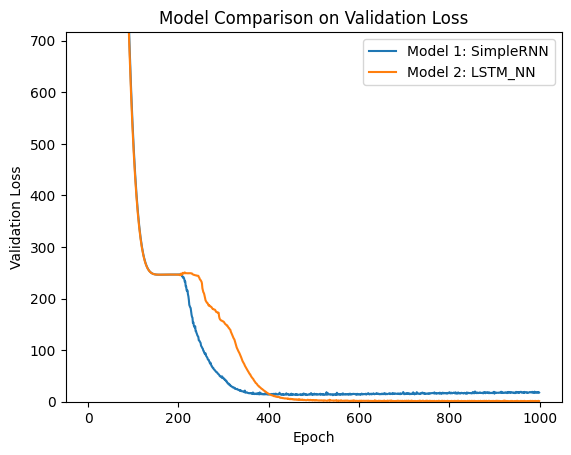

6/6 [==============================] - 0s 3ms/step - loss: 0.4145


In [9]:
# Using the model builder
builder = DNNModelBuilder(x_train, [SimpleRNN, LSTM_NN])

builder.train(x_train, y_train, epochs=1000, batch_size=64, validation_split=0.2)
builder.compare_models()
losses = builder.evaluate(x_test, y_test)
# print(losses)
# builder.save_models()

# 6m45s (in notes) RNN loss: ~17, LSTM loss: ~1.5

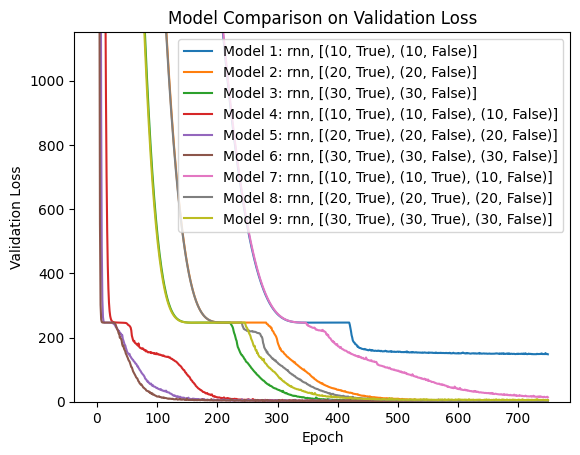

6/6 [==============================] - 0s 2ms/step - loss: 1.0586
[106.20306396484375, 1.6172974109649658, 1.1407732963562012, 2.5253405570983887, 1.2351620197296143, 1.4720796346664429, 10.941502571105957, 2.0764577388763428, 1.0585601329803467]


In [44]:
# Using the model builder
# builder = DNNModelBuilder(x_train, [
#     # (rnn, [[(10, False)]]),
#     # (rnn, [[(20, False)]]),
#     # (rnn, [[(30, False)]]),
#     (rnn, [[(10, True), (10, False)]]),
#     (rnn, [[(20, True), (20, False)]]),
#     (rnn, [[(30, True), (30, False)]]),
#     (rnn, [[(10, True), (10, False), (10, False)]]),
#     (rnn, [[(20, True), (20, False), (20, False)]]),
#     (rnn, [[(30, True), (30, False), (30, False)]]),
#     (rnn, [[(10, True), (10, True), (10, False)]]),
#     (rnn, [[(20, True), (20, True), (20, False)]]),
#     (rnn, [[(30, True), (30, True), (30, False)]]),
    # ])

# builder.train(x_train, y_train, epochs=750, batch_size=64, validation_split=0.2)
builder.compare_models()
losses = builder.evaluate(x_test, y_test)
print(losses)
# builder.save_models()

# 13m21

In [46]:
pred = builder.predict(x_test)

for i, p in enumerate(pred):
    # plot_positions_comparison(np.array(y_test), np.array(p))
    rel_err = np.abs(np.linalg.norm(p - y_test, axis=1)) / np.abs(np.linalg.norm(y_test, axis=1)) * 100
    scale_err = np.abs(np.linalg.norm(p - y_test, axis=1)) / (np.max(y_test[:,0]) - np.min(y_test[:,0])) * 100
    print(f"\nArchitechture: {str(builder.architectures[i][0]).split(' ')[1]}, {builder.architectures[i][1][0]}")
    print(f"Mean Relative Error: {np.mean(rel_err):.3f}%")
    print(f"Max Relative Error: {max(rel_err):.3f}%")
    print(f"Mean Relative Full-Scale Erroc: {np.mean(scale_err):.3f}%")
    print(f"Max Relative Full-Scale Error: {max(scale_err):.3f}%")

    

6/6 [==============================] - 0s 2ms/step

Architechture: rnn, [(10, True), (10, False)]
Mean Relative Error: 8.126%
Max Relative Error: 18.361%
Mean Relative Full-Scale Error: 27.573%
Max Relative Full-Scale Error: 64.354%

Architechture: rnn, [(20, True), (20, False)]
Mean Relative Error: 1.020%
Max Relative Error: 2.807%
Mean Relative Full-Scale Error: 3.443%
Max Relative Full-Scale Error: 9.741%

Architechture: rnn, [(30, True), (30, False)]
Mean Relative Error: 0.865%
Max Relative Error: 2.480%
Mean Relative Full-Scale Error: 2.878%
Max Relative Full-Scale Error: 8.154%

Architechture: rnn, [(10, True), (10, False), (10, False)]
Mean Relative Error: 1.283%
Max Relative Error: 3.044%
Mean Relative Full-Scale Error: 4.386%
Max Relative Full-Scale Error: 11.453%

Architechture: rnn, [(20, True), (20, False), (20, False)]
Mean Relative Error: 0.919%
Max Relative Error: 2.978%
Mean Relative Full-Scale Error: 3.079%
Max Relative Full-Scale Error: 9.762%

Architechture: rnn, [(3

(3177, 3, 1) | (3, 1) | [(10, True), (10, False)]
(3177, 3, 1) | (3, 1) | [(20, True), (20, False)]
(3177, 3, 1) | (3, 1) | [(30, True), (30, False)]
(3177, 3, 1) | (3, 1) | [(10, True), (10, False), (10, False)]
(3177, 3, 1) | (3, 1) | [(20, True), (20, False), (20, False)]
(3177, 3, 1) | (3, 1) | [(30, True), (30, False), (30, False)]
(3177, 3, 1) | (3, 1) | [(10, True), (10, True), (10, False)]
(3177, 3, 1) | (3, 1) | [(20, True), (20, True), (20, False)]
(3177, 3, 1) | (3, 1) | [(30, True), (30, True), (30, False)]
Training model 1/9
Training model 2/9
Training model 3/9
Training model 4/9
Training model 5/9
Training model 6/9
Training model 7/9
Training model 8/9
Training model 9/9


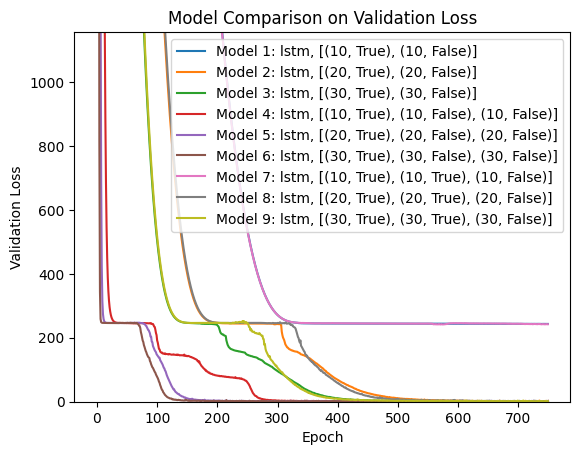

6/6 [==============================] - 0s 3ms/step - loss: 0.4204


In [62]:
builder = DNNModelBuilder(x_train, [    
    # (lstm, [[(10, False)]]),
    # (lstm, [[(20, False)]]),
    # (lstm, [[(30, False)]]),
    (lstm, [[(10, True), (10, False)]]),
    (lstm, [[(20, True), (20, False)]]),
    (lstm, [[(30, True), (30, False)]]),
    (lstm, [[(10, True), (10, False), (10, False)]]),
    (lstm, [[(20, True), (20, False), (20, False)]]),
    (lstm, [[(30, True), (30, False), (30, False)]]),
    (lstm, [[(10, True), (10, True), (10, False)]]),
    (lstm, [[(20, True), (20, True), (20, False)]]),
    (lstm, [[(30, True), (30, True), (30, False)]]),
    ])

builder.train(x_train, y_train, epochs=750, batch_size=64, validation_split=0.2)
builder.compare_models()
losses = builder.evaluate(x_test, y_test)
# print(losses)

# 29m14

In [63]:
pred = builder.predict(x_test)

for i, p in enumerate(pred):
    # plot_positions_comparison(np.array(y_test), np.array(p))
    abs_err = np.abs(np.linalg.norm(p - y_test, axis=1))
    rel_err = abs_err / np.abs(np.linalg.norm(y_test, axis=1)) * 100
    scale_err = abs_err / (np.max(y_test[:,0]) - np.min(y_test[:,0])) * 100
    print(f"\nArchitechture: {str(builder.architectures[i][0]).split(' ')[1]}, {builder.architectures[i][1][0]}")
    print(f"Mean Relative Error: {np.mean(rel_err):.3f}%")
    print(f"Max Relative Error: {max(rel_err):.3f}%")
    print(f"Mean Relative Full-Scale Erroc: {np.mean(scale_err):.3f}%")
    print(f"Max Relative Full-Scale Error: {max(scale_err):.3f}%")
    print(f"Mean Absolute Error: {np.mean(np.linalg.norm(abs_err, axis=1))}")

    

6/6 [==============================] - 1s 5ms/step

Architechture: lstm, [(10, True), (10, False)]
Mean Relative Error: 15.983%
Max Relative Error: 34.621%
Mean Relative Full-Scale Erroc: 53.579%
Max Relative Full-Scale Error: 89.492%

Architechture: lstm, [(20, True), (20, False)]
Mean Relative Error: 0.749%
Max Relative Error: 1.790%
Mean Relative Full-Scale Erroc: 2.497%
Max Relative Full-Scale Error: 6.507%

Architechture: lstm, [(30, True), (30, False)]
Mean Relative Error: 0.646%
Max Relative Error: 1.580%
Mean Relative Full-Scale Erroc: 2.111%
Max Relative Full-Scale Error: 4.416%

Architechture: lstm, [(10, True), (10, False), (10, False)]
Mean Relative Error: 0.622%
Max Relative Error: 1.697%
Mean Relative Full-Scale Erroc: 2.096%
Max Relative Full-Scale Error: 6.674%

Architechture: lstm, [(20, True), (20, False), (20, False)]
Mean Relative Error: 0.713%
Max Relative Error: 2.817%
Mean Relative Full-Scale Erroc: 2.457%
Max Relative Full-Scale Error: 9.872%

Architechture: lst